In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from itertools import combinations
from fastdtw import fastdtw
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

In [ ]:
# set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [14]:
# fetch dataset 
multivariate_gait_data = fetch_ucirepo(id=760)
df = multivariate_gait_data.data.features

In [15]:
# randomly select training/testing subjects (80/20 split)
# split data by subjects to avoid data leakage
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

train = df[df["subject"].isin(train_subjects)]
test = df[df["subject"].isin(test_subjects)]

In [ ]:
def construct_sequences(df):
    """ 
    Construct sequences of leg/joint angles over time 
    Each sequence has shape 101 x 6 (101 points in time x 6 angles)
    """
    grouped = df.groupby(["subject", "condition", "replication"])

    labels = []
    sequences = []

    for id, group in grouped:
        # condition at index 1 in the groupby
        labels.append(id[1])
        # get measurements for each leg and joint combination over time
        pivot = group.pivot_table(
            index="time", 
            columns=["leg", "joint"], 
            values="angle"
        )
        sequences.append(pivot.values)

    sequences = np.array(sequences)
    labels = np.array(labels)

    return sequences, labels

In [17]:
# format the data for training and testing
X_train, y_train = construct_sequences(train)
X_test, y_test = construct_sequences(test)

# flatten the data to apply standardization
n_instances, n_timepts, n_features = X_train.shape
X_train_flat = X_train.reshape(-1, n_features)
X_test_flat = X_test.reshape(-1, n_features)

# scale the data and reshape it into a 3D tensor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_flat).reshape(n_instances, n_timepts, n_features)
X_test = scaler.transform(X_test_flat).reshape(-1, n_timepts, n_features)

# 0-indexed labels
y_train = y_train - 1
y_test = y_test - 1

In [18]:
X_train.shape

(240, 101, 6)

### kNN with Dynamic Time Warping (DTW)

In [19]:
TARGET_NAMES = [f"Cond {i+1}" for i in range(3)]

In [20]:
accs = []
max_k = 10
for i in range(1, max_k):
    knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=i, metric="dtw")
    knn_dtw.fit(X_train, y_train)
    accs.append(knn_dtw.score(X_test, y_test))

Text(0.5, 1.0, 'Accuracy with Different k-values')

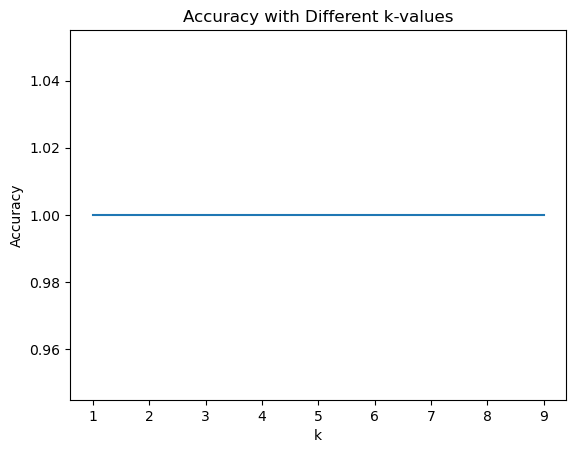

In [21]:
plt.plot(range(1, max_k), accs)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy with Different k-values")

The choice of k does not seem to affect accuracy.

In [22]:
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric="dtw")
knn_dtw.fit(X_train, y_train)
predicted = knn_dtw.predict(X_test)
predicted_proba = knn_dtw.predict_proba(X_test)
print(classification_report(y_test, predicted, target_names=TARGET_NAMES))
print(f"AUC: {roc_auc_score(y_test, predicted_proba, multi_class='ovr')}")

              precision    recall  f1-score   support

      Cond 1       1.00      1.00      1.00        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

AUC: 1.0


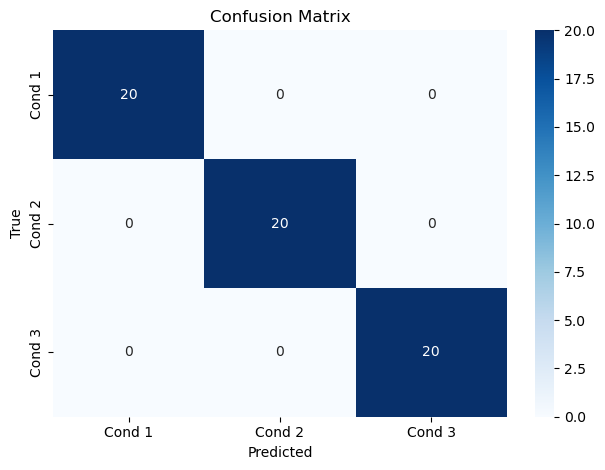

In [ ]:
n_classes = len(np.unique(y_train))
LABELS = [f"Condition {i+1}" for i in range(n_classes)]

cm = confusion_matrix(y_test, predicted)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)],
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

To explore why kNN-DTW has perfect performance, we compared the average DTW distances within the same class versus between different classes.

In [24]:
intra, inter = [], []

# calculate similarities between different sequences in the training data
for (i, j) in combinations(range(len(X_train)), 2):
    d, _ = fastdtw(X_train[i], X_train[j])
    (intra if y_train[i] == y_train[j] else inter).append(d)

print("Mean intra-class DTW:", np.mean(intra))
print("Mean inter-class DTW:", np.mean(inter))

Mean intra-class DTW: 194.40978663215935
Mean inter-class DTW: 334.6794539631265


**Analysis:**

The lower mean intra-class distance and higher mean inter-class distance indicates that sequences belonging to the same condition exhibit strong similarity, whereas sequences from different classes are more dissimilar.

The model achieving perfect metrics is more likely due to the high separability between classes rather than data leakage. However, it should be considered that data collected under less controlled environments may contain more noise or variability that interferes with separability, which may impact model performance.

### kNN-Euclidean

Since kNN-DTW performed so well, we wanted to examine a simpler distance metric. Since the data is already fixed within timesteps from 0% to 100%, it's possible that Euclidean distance is sufficient for kNN instead of a more complex similarity metric.

In [25]:
knn_euclidean = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric="euclidean")
knn_euclidean.fit(X_train, y_train)
predicted = knn_dtw.predict(X_test)
predicted_proba = knn_dtw.predict_proba(X_test)
print(classification_report(y_test, predicted, target_names=TARGET_NAMES))
print(f"AUC: {roc_auc_score(y_test, predicted_proba, multi_class='ovr')}")

              precision    recall  f1-score   support

      Cond 1       1.00      1.00      1.00        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

AUC: 1.0


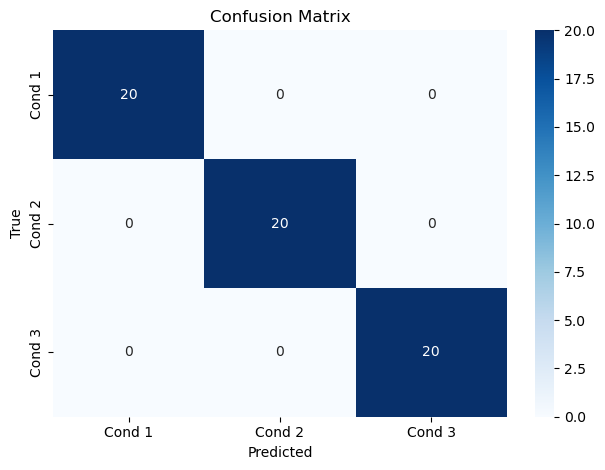

In [ ]:
cm = confusion_matrix(y_test, predicted)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)],
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Analysis:**

kNN-Euclidean also performs perfectly on the data.

### LSTM

In [27]:
# convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test)

In [28]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

In [29]:
# define a single layer model as a baseline
class LSTM1(nn.Module):
    def __init__(self, n_features, n_classes, n_hidden=32, dropout_rate=0.3):
        """
        Initialize the architecture with 1 hidden layer
        """
        super().__init__()

        # single hidden layer
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=1,
            batch_first=True
        )

        # dropout layer for regularization
        self.dropout = nn.Dropout(dropout_rate)

        self.fc = nn.Linear(n_hidden, n_classes)

    def forward(self, x):
        """
        Forward propagate a batch of trials x through the model and return a prediction for each
        (a single trial = one subject in one replication under one condition)
        """
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)

In [30]:
# define the number of classes
n_classes = len(y_train.unique())

In [31]:
def plot_loss(n_epochs, loss_history):
    plt.plot(range(1, n_epochs + 1), loss_history)
    plt.title("Loss History")
    plt.xlabel("Number of Epochs")
    plt.ylabel("Loss")
    plt.show()

In [32]:
def train_model(model, optimizer, criterion, n_epochs=100):
    """ Trains the model and plots the loss history """
    loss_history = []

    for epoch in range(n_epochs):
        # set model to training mode
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            # clear gradients from previous batch
            optimizer.zero_grad()
            # compute loss between predictions and true labels
            loss = criterion(model(X_batch), y_batch)
            # backpropagate the loss
            loss.backward()
            # update model weights
            optimizer.step()
            # accumulate batch loss
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}  loss: {avg_loss:.4f}")
        
    plot_loss(n_epochs, loss_history)
    return loss_history

In [33]:
def test_model(model, X_test):
    """ Tests the model and returns (predicted values, predicted probabilities) """
    # set model to evaluation mode
    model.eval()

    # disable gradient tracking since we're not training
    with torch.no_grad():
        # run test trials through model, output one score per condition
        logits = model(X_test)
        # take the highest score as the predicted condition
        predicted = logits.argmax(dim=1).numpy()
        probs = torch.softmax(logits, dim=1)
    return predicted, probs

In [34]:
def display_metrics(y_true, predicted, probs, labels=LABELS):
    print(classification_report(y_true, predicted, target_names=TARGET_NAMES))
    print(f"AUC: {roc_auc_score(y_true, probs, multi_class='ovr'):.4f}")

    cm1 = confusion_matrix(y_true, predicted)
    sns.heatmap(
        cm1, annot=True, cmap="Blues",
        xticklabels=labels, yticklabels=labels
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.show()

### Model 1
*1 hidden layer with 32 neurons and a dropout rate of 0.3*

Epoch 10/100  loss: 0.4003
Epoch 20/100  loss: 0.1047
Epoch 30/100  loss: 0.1049
Epoch 40/100  loss: 0.0500
Epoch 50/100  loss: 0.0351
Epoch 60/100  loss: 0.0182
Epoch 70/100  loss: 0.0083
Epoch 80/100  loss: 0.0063
Epoch 90/100  loss: 0.0045
Epoch 100/100  loss: 0.0035


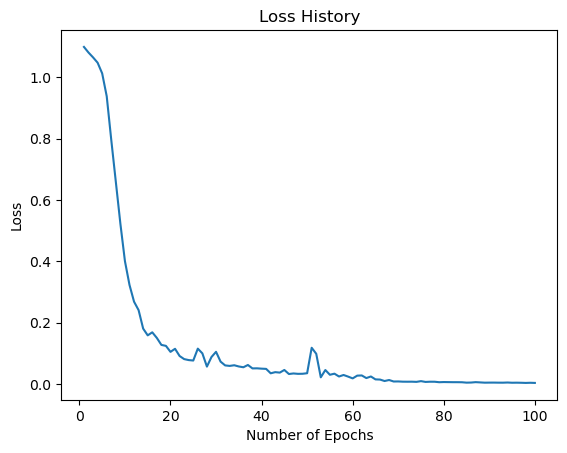

In [48]:
model1 = LSTM1(n_features=n_features, n_classes=n_classes)
optimizer1 = torch.optim.Adam(model1.parameters())
# definition of cross entropy loss in PyTorch takes in label encodings
criterion = nn.CrossEntropyLoss()

n_epochs = 100
loss_history1 = train_model(model1, optimizer1, criterion, n_epochs=n_epochs)

              precision    recall  f1-score   support

      Cond 1       0.66      0.95      0.78        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       0.91      0.50      0.65        20

    accuracy                           0.82        60
   macro avg       0.85      0.82      0.81        60
weighted avg       0.85      0.82      0.81        60

AUC: 0.9308


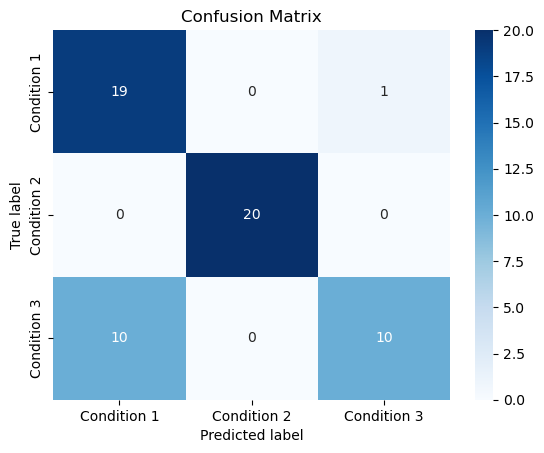

In [49]:
pred1, probs1 = test_model(model1, X_test)
display_metrics(y_test, pred1, probs1)

**Analysis:**

The model performs well on the data, but not as perfectly as with the simpler models used on the tabular data.

### Model 2
*1 hidden layer with 64 neurons and a dropout rate of 0.3*

Epoch 10/100  loss: 0.0038
Epoch 20/100  loss: 0.0039
Epoch 30/100  loss: 0.0029
Epoch 40/100  loss: 0.0029
Epoch 50/100  loss: 0.0028
Epoch 60/100  loss: 0.0034
Epoch 70/100  loss: 0.0024
Epoch 80/100  loss: 0.0020
Epoch 90/100  loss: 0.0015
Epoch 100/100  loss: 0.0009


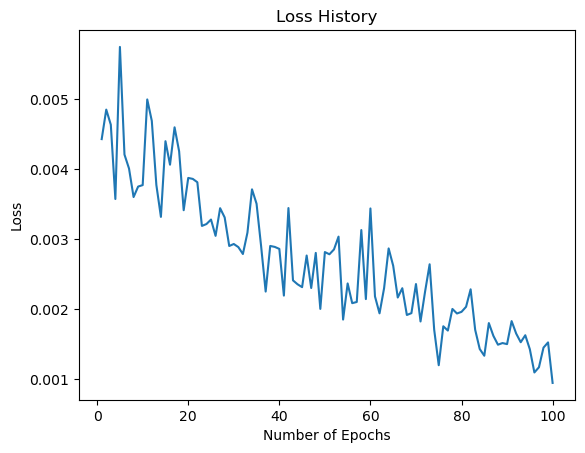

In [ ]:
model2 = LSTM1(n_features=n_features, n_classes=n_classes, n_hidden=64, dropout_rate=0.3)
optimizer2 = torch.optim.Adam(model2.parameters())
criterion = nn.CrossEntropyLoss()

n_epochs = 100
loss_history2 = train_model(model1, optimizer1, criterion, n_epochs=n_epochs)

              precision    recall  f1-score   support

      Cond 1       0.00      0.00      0.00        20
      Cond 2       0.33      1.00      0.50        20
      Cond 3       0.00      0.00      0.00        20

    accuracy                           0.33        60
   macro avg       0.11      0.33      0.17        60
weighted avg       0.11      0.33      0.17        60

AUC: 0.6704


/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


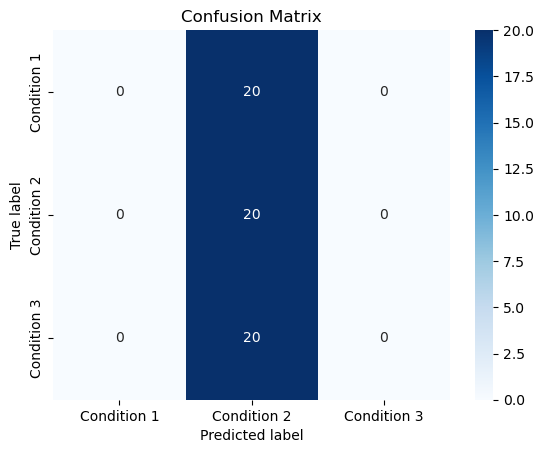

In [38]:
pred2, probs2 = test_model(model2, X_test)
display_metrics(y_test, pred2, probs2)

**Analysis:**

Increasing the number of neurons resulted in a useless model that predicts only one class. 64 neurons is likely too many neurons for a smaller dataset with only 300 sequences.

### Model 3

*2 hidden layers with 64 neurons and a dropout rate of 0.3*

In [39]:
class LSTM2(nn.Module):
    def __init__(self, n_features, n_classes, n_hidden=32, dropout_rate=0.3):
        """
        Initialize the architecture with 2 hidden layers
        """
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=2,
            dropout=dropout_rate,
            batch_first=True
        )
        
        # dropout layer for regularization
        self.dropout = nn.Dropout(dropout_rate)

        self.fc = nn.Linear(n_hidden, n_classes)

    def forward(self, x):
        """
        Forward propagate a batch of trials x through the model and return a prediction for each
        (a single trial = one subject in one replication under one condition)
        """
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)

Epoch 10/100  loss: 0.1756
Epoch 20/100  loss: 0.0275
Epoch 30/100  loss: 0.0035
Epoch 40/100  loss: 0.0021
Epoch 50/100  loss: 0.0016
Epoch 60/100  loss: 0.0012
Epoch 70/100  loss: 0.0011
Epoch 80/100  loss: 0.0006
Epoch 90/100  loss: 0.0006
Epoch 100/100  loss: 0.0005


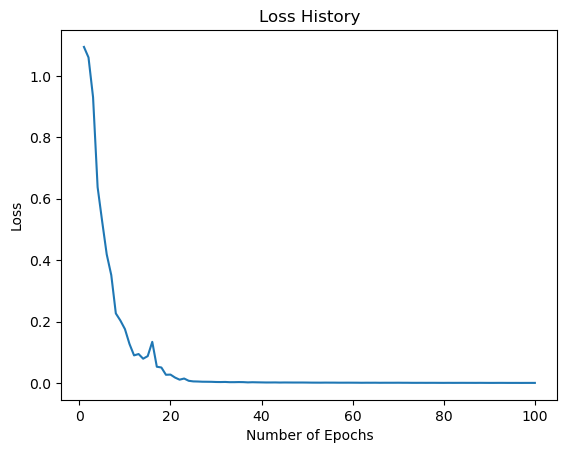

In [ ]:
model3 = LSTM2(n_features=n_features, n_classes=n_classes, n_hidden=64)
optimizer3 = torch.optim.Adam(model3.parameters())
criterion = nn.CrossEntropyLoss()

n_epochs = 100
loss_history3 = train_model(model3, optimizer3, criterion, n_epochs=n_epochs)

              precision    recall  f1-score   support

      Cond 1       0.60      0.75      0.67        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       0.67      0.50      0.57        20

    accuracy                           0.75        60
   macro avg       0.76      0.75      0.75        60
weighted avg       0.76      0.75      0.75        60

AUC: 0.8700


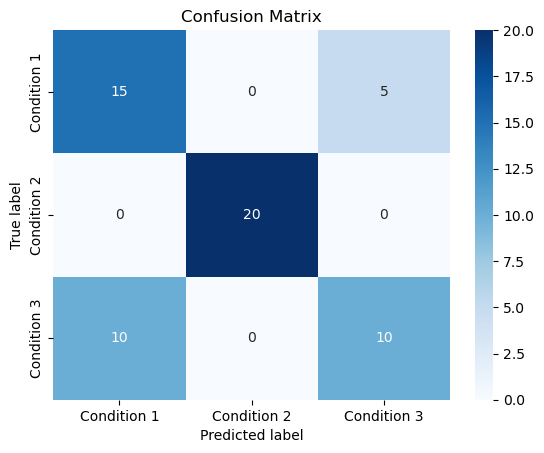

In [41]:
pred3, probs3 = test_model(model3, X_test)
display_metrics(y_test, pred3, probs3)

**Analysis:**

With 2 hidden layers, the model benefitted from a greater number of neurons. However, this model performed worse on most metrics compared to Model 1. This suggests that simpler models perform better on this dataset. Both Model 1 and Model 3 models struggled with distinguishing Condition 1 and Condition 3, which indicates that these conditions share some similarities.

### CNN-LSTM

In [50]:
# select a subset of the data to observe how leg/joint angles are stored
train[train["condition"] == 1].pivot_table(
    index="time", 
    columns=["joint", "leg"], 
    values="angle"
)

joint         1                    2                     3           
leg           1         2          1          2          1          2
time                                                                 
0      5.274015  3.607948   2.717795   5.190196  21.087335  22.104791
1      5.371269  3.643509   3.046923   5.361224  21.113498  21.993044
2      5.152508  3.386257   3.892927   6.032702  21.189812  21.933795
3      4.589831  2.802896   5.051092   7.016472  21.249642  21.870795
4      3.725933  1.934595   6.334673   8.144198  21.239809  21.759201
...         ...       ...        ...        ...        ...        ...
96     3.712415  2.524667  10.127565  13.018862  22.673577  24.102658
97     3.958907  2.675228   7.082240   9.965197  22.020648  23.416907
98     4.354437  2.955063   4.792808   7.616223  21.526066  22.856559
99     4.796613  3.294030   3.341966   6.062679  21.211938  22.448989
100    5.160505  3.588922   2.726893   5.310289  21.069688  22.193362

[101 rows x 6 columns]

In [ ]:
class CNN_LSTM(nn.Module):
    def __init__(self, n_classes, dropout_rate=0.3):
        """
        Initialize the architecture
        """
        super().__init__()

        # each joint
        self.ankle = nn.Sequential(
            # greater number of out channels for ankle due to difficulties with classifying condition 3
            nn.Conv1d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(2)
        )
        self.knee = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(2)
        )
        self.hip = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(2)
        )

        # all joints
        self.joints_convolution = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(2)
        )

        self.lstm = nn.LSTM(32, 64, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        """
        Forward propagate a batch of trials x
        """
        # swap timesteps and joint angle positions to work with Conv1d
        x = x.permute(0, 2, 1)

        # extract individual joint angles
        ankle_input = x[:, 0:2, :]
        knee_input  = x[:, 2:4, :]
        hip_input   = x[:, 4:6, :]

        # apply convolutions to each joint
        ankle_output = self.ankle(ankle_input)
        knee_output  = self.knee(knee_input)
        hip_output   = self.hip(hip_input)

        # combine individual joint outputs and apply another convolution
        combined = torch.cat([ankle_output, knee_output, hip_output], dim=1)
        combined = self.joints_convolution(combined)
        
        # swap timesteps and joint angle positions to work with LSTM
        combined = combined.permute(0, 2, 1)
        _, (hidden, _) = self.lstm(combined)
        out = self.dropout(hidden[-1])
        return self.classifier(out)

Epoch 10/100  loss: 0.0001
Epoch 20/100  loss: 0.0001
Epoch 30/100  loss: 0.0001
Epoch 40/100  loss: 0.0001
Epoch 50/100  loss: 0.0001
Epoch 60/100  loss: 0.0001
Epoch 70/100  loss: 0.0001
Epoch 80/100  loss: 0.0001
Epoch 90/100  loss: 0.0001
Epoch 100/100  loss: 0.0001


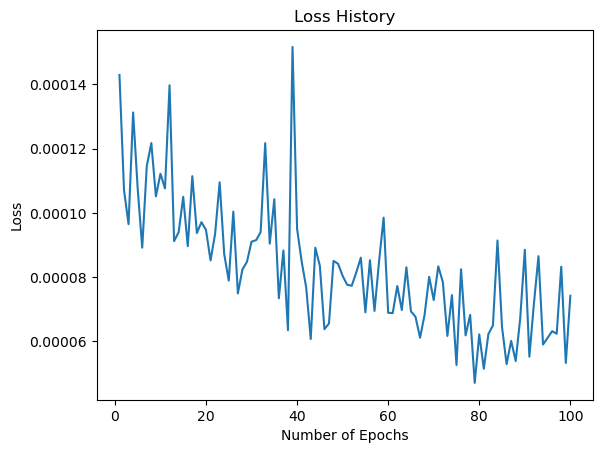

In [66]:
model4 = CNN_LSTM(n_classes=n_classes)
optimizer4 = torch.optim.Adam(model4.parameters())
criterion = nn.CrossEntropyLoss()

n_epochs = 100
loss_history4 = train_model(model3, optimizer3, criterion, n_epochs=n_epochs)

              precision    recall  f1-score   support

      Cond 1       0.67      1.00      0.80        20
      Cond 2       1.00      0.90      0.95        20
      Cond 3       0.92      0.55      0.69        20

    accuracy                           0.82        60
   macro avg       0.86      0.82      0.81        60
weighted avg       0.86      0.82      0.81        60

AUC: 0.9508


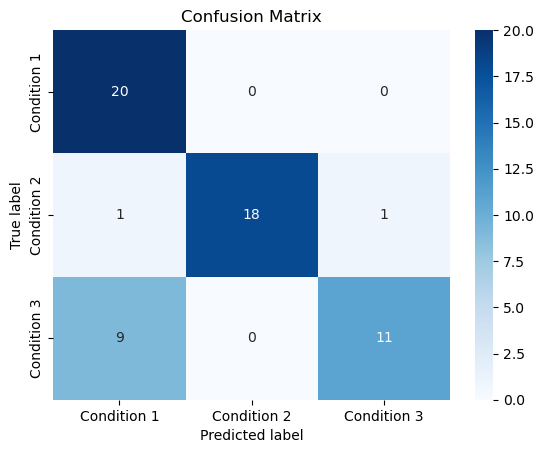

In [67]:
pred4, probs4 = test_model(model3, X_test)
display_metrics(y_test, pred4, probs4)

**Analysis:**

The CNN-LSTM model still struggles to classify Condition 3 despite attempts to capture more information about the ankle data by asymmetrically increasing the number of filters applied to ankle data. The model performs similarly to Model 1.

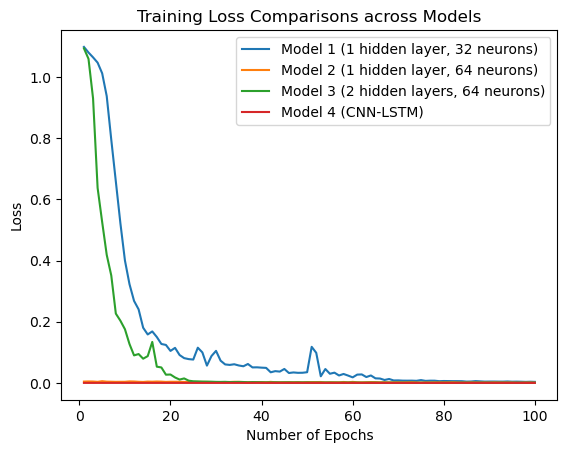

In [68]:
epochs = range(1, n_epochs + 1)
plt.plot(epochs, loss_history1, label="Model 1 (1 hidden layer, 32 neurons)")
plt.plot(epochs, loss_history2, label="Model 2 (1 hidden layer, 64 neurons)")
plt.plot(epochs, loss_history3, label="Model 3 (2 hidden layers, 64 neurons)")
plt.plot(epochs, loss_history4, label="Model 4 (CNN-LSTM)")
plt.title("Training Loss Comparisons across Models")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Analysis:**

Although Model 2 has one of the lowest training losses compared to the other models, it performs the worst on the testing data. This indicates that Model 2 is overfitting. Models 2 and 4 immediately achieve extremely low training loss, but Models 1 and 3 require more epochs to minimize loss.

### Adding noise to data

In [115]:
noise = torch.tensor(np.random.normal(0, 3, X_test.shape), dtype=torch.float32)
X_test_noisy = X_test + noise

              precision    recall  f1-score   support

      Cond 1       0.87      1.00      0.93        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       1.00      0.85      0.92        20

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.96      0.95      0.95        60

AUC: 0.9625


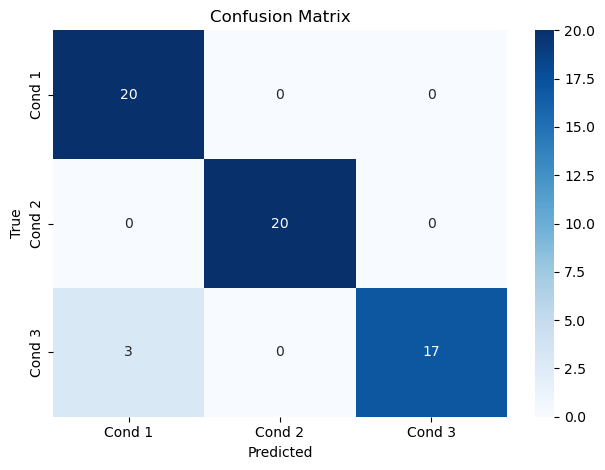

In [116]:
pred_noisy = knn_dtw.predict(X_test_noisy)
proba_noisy = knn_dtw.predict_proba(X_test_noisy)

print(classification_report(y_test, pred_noisy, target_names=TARGET_NAMES))
print(f"AUC: {roc_auc_score(y_test, proba_noisy, multi_class='ovr')}")

cm = confusion_matrix(y_test, pred_noisy)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)],
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      Cond 1       0.44      0.55      0.49        20
      Cond 2       0.63      0.85      0.72        20
      Cond 3       0.75      0.30      0.43        20

    accuracy                           0.57        60
   macro avg       0.61      0.57      0.55        60
weighted avg       0.61      0.57      0.55        60

AUC: 0.7412


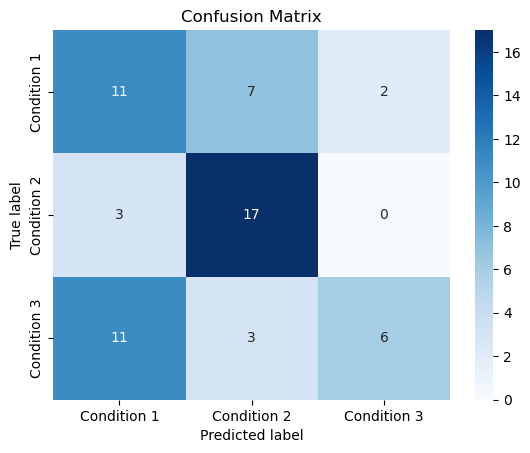

In [117]:
pred_noisy, proba_noisy = test_model(model1, X_test_noisy)
display_metrics(y_test, pred_noisy, proba_noisy)

              precision    recall  f1-score   support

      Cond 1       0.00      0.00      0.00        20
      Cond 2       0.00      0.00      0.00        20
      Cond 3       0.34      1.00      0.51        20

    accuracy                           0.33        60
   macro avg       0.11      0.33      0.17        60
weighted avg       0.11      0.33      0.17        60

AUC: 0.6017


/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ts/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


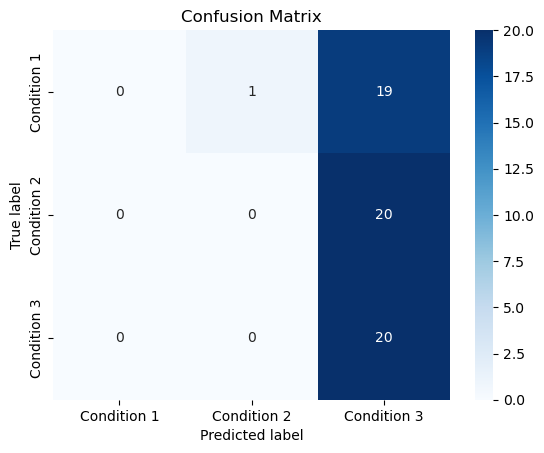

In [121]:
pred_noisy, proba_noisy = test_model(model4, X_test_noisy)
display_metrics(y_test, pred_noisy, proba_noisy)

**Analysis:**

The kNN model performs extremely well despite noisy data. Model 1 struggles more with noisy data but is still usable. Model 4 becomes useless when noisy data is introduced.